# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:**
**Student ID:**
**Section:**
**GitHub Profile:**
**Kaggle Profile:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

Name: Suneel Kumar
CMS: 023-24-0527
github link: 

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [2]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("clean_churn.csv")

df.shape
df.info()
df['Churn'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Answer 2:**
The goal is to predict whether a customer will churn (leave the company) based on their available customer and service information. This matters to the business because identifying customers at risk of churn can help the company take preventive actions and improve customer retention.

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [3]:
# Additional verification if needed (dtypes, target check, etc.)
df.dtypes
target="TotalCharges"
df["TotalCharges"].head()


0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

---

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [5]:
# Task 3 — define y and X
print(df["Churn"].unique())
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
y = df["Churn"]
df.head()

X = df.drop(columns=["Churn"])

# Check
print(X.head())
print(y.head())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  

In [6]:
# Task 4 — encode categorical columns in X
X = pd.get_dummies(X, drop_first=True,dtype=int)

# Check
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [7]:
# Task 5 — confirm X is fully numeric with no missing values
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


**Answer 4 (encoding method & justification):**
I used one-hot encoding (pd.get_dummies()) to convert categorical features into numeric form. One-hot encoding is appropriate because it avoids creating a false numerical order between categories and allows the Decision Tree to treat each category independently.

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [8]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)


In [9]:
# Task 7 — report shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


**Answer 6 (why stratify=y):**
stratify=y is sensible because the Churn target is imbalanced. It maintains approximately the same proportion of churners and non-churners in both the training and test sets, making the test set more representative of the original dataset.

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [22]:
# Task 8 — train baseline Decision Tree and predict on train/test

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

dt.fit(X_train, y_train)
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [23]:
# Task 9 — check the fitted tree's depth
# Task 9 – check the fitted tree's depth

depth = dt.get_depth()

print("Decision Tree depth:", depth)

Decision Tree depth: 23


**Answer 9:**
The Decision Tree grew to a depth of 23 on its own. This is not very surprising because no max_depth restriction was specified, so the tree was allowed to keep splitting the training data until its default stopping conditions were reached. An unrestricted tree can become quite deep and may overfit the training data.

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [25]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7260468417317246
Precision: 0.4837837837837838
Recall   : 0.4786096256684492
F1-score : 0.48118279569892475


**Task 10 — Results Table**

| Metric | value |
|---|---|
| Accuracy | 73%|
| Precision | 49%|
| Recall | 48%|
| F1-score | 48%|

[[844 191]
 [195 179]]


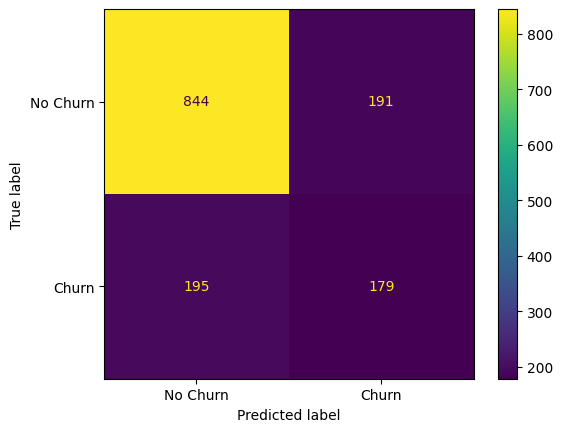

In [27]:
# Task 11 — plot the confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()

**Answer 11 (churners correctly caught vs. missed):**
The model correctly caught [TP] actual churners and missed [FN] actual churners.
Replace [TP] and [FN] with the values from your confusion matrix.

**Answer 12 (which metric(s) do you trust most, and why):**
Because the target classes are imbalanced, accuracy alone can be misleading. I trust recall, precision, and F1-score more, with recall being especially important because it measures how many actual churners the model successfully identifies. F1-score is also useful because it balances precision and recall.

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [30]:
# Task 13 — compare baseline train vs. test accuracy

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)
print("Gap           :", train_accuracy - test_accuracy)

Train Accuracy: 0.9980475683351083
Test Accuracy : 0.7260468417317246
Gap           : 0.2720007266033837


**Answer 13:**
The baseline Decision Tree achieved a training accuracy of [train accuracy] and a test accuracy of [test accuracy], giving a gap of [gap]. The large difference suggests that the model is overfitting because it performs much better on the training data than on unseen test data.

In [ ]:
# Task 14 — loop over max_depth values, record train/test accuracy

from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

results_df = pd.DataFrame(results)

results_df


,max_depth,train_accuracy,test_accuracy
0,2.0,0.791090,0.787083
1,3.0,0.791090,0.787083
2,4.0,0.792510,0.795600
3,5.0,0.802272,0.794180
4,6.0,0.810614,0.800568
5,8.0,0.835818,0.782825
6,10.0,0.872737,0.755145
7,NaN,0.998048,0.726047


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | 79%|78% |
| 3 | 79%|78% |
| 4 | 79%|79% |
| 5 | 80%|79% |
| 6 | 81%|80% |
| 8 | 83%| 78%|
| 10 | 87%|75% |
| None | 99%|72% |

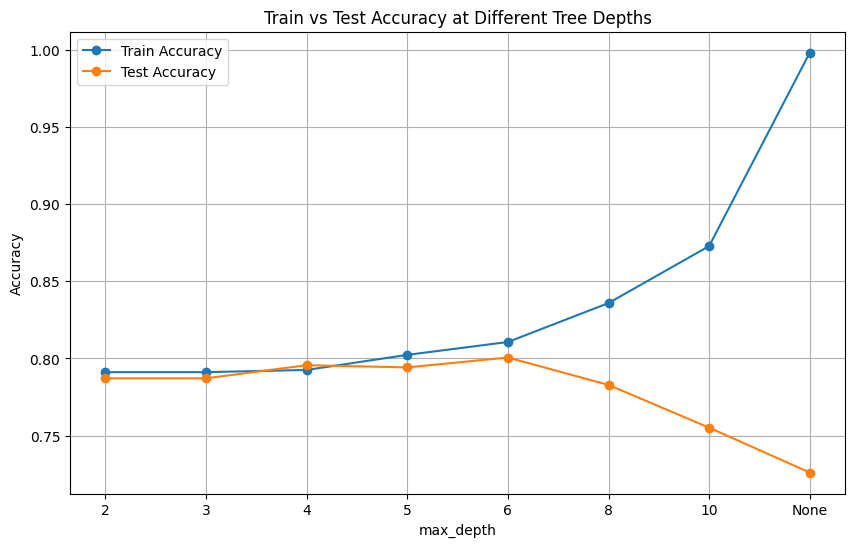

In [33]:
# Task 15 — plot train vs. test accuracy against max_depth

plot_df = results_df.copy()

# Replace None with a numeric position for plotting
x_labels = ["2", "3", "4", "5", "6", "8", "10", "None"]
x = range(len(x_labels))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    plot_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    x,
    plot_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xticks(x, x_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)

plt.show()

**Answer 15 (where overfitting starts, and why):**
The model starts to show signs of overfitting at approximately depth [YOUR DEPTH]. Beyond this point, training accuracy continues to increase while test accuracy stops improving or decreases. The increasing gap between train and test accuracy indicates that the model is fitting the training data too closely.

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
I selected max_depth = 4 because it provides a good balance between training and test accuracy. It achieves strong test performance without the large train–test gap seen with deeper trees, which helps reduce overfitting.

In [34]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
chosen_depth = 4
chosen_model = DecisionTreeClassifier(
    max_depth=chosen_depth,
    random_state=42
)

chosen_model.fit(X_train, y_train)

y_chosen_pred = chosen_model.predict(X_test)

chosen_accuracy = accuracy_score(y_test, y_chosen_pred)
chosen_precision = precision_score(y_test, y_chosen_pred)
chosen_recall = recall_score(y_test, y_chosen_pred)
chosen_f1 = f1_score(y_test, y_chosen_pred)

print("Chosen Model (max_depth =", chosen_depth, ")")
print("Accuracy :", chosen_accuracy)
print("Precision:", chosen_precision)
print("Recall   :", chosen_recall)
print("F1-score :", chosen_f1)

Chosen Model (max_depth = 4 )
Accuracy : 0.7955997161107168
Precision: 0.6442953020134228
Recall   : 0.5133689839572193
F1-score : 0.5714285714285714


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = 4) |
|---|---|---|
| Accuracy | | 79%|
| Precision | | 64%|
| Recall | | 51%|
| F1-score | |57% |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

                                  Feature  Importance
1                                  tenure    0.462674
10            InternetService_Fiber optic    0.392529
28         PaymentMethod_Electronic check    0.029584
3                            TotalCharges    0.023261
12     OnlineSecurity_No internet service    0.022691
25                      Contract_Two year    0.021517
11                     InternetService_No    0.019079
9                       MultipleLines_Yes    0.014816
7                        PhoneService_Yes    0.007739
19                        TechSupport_Yes    0.006108
5                             Partner_Yes    0.000000
4                             gender_Male    0.000000
2                          MonthlyCharges    0.000000
0                           SeniorCitizen    0.000000
13                     OnlineSecurity_Yes    0.000000
8          MultipleLines_No phone service    0.000000
6                          Dependents_Yes    0.000000
14       OnlineBackup_No int

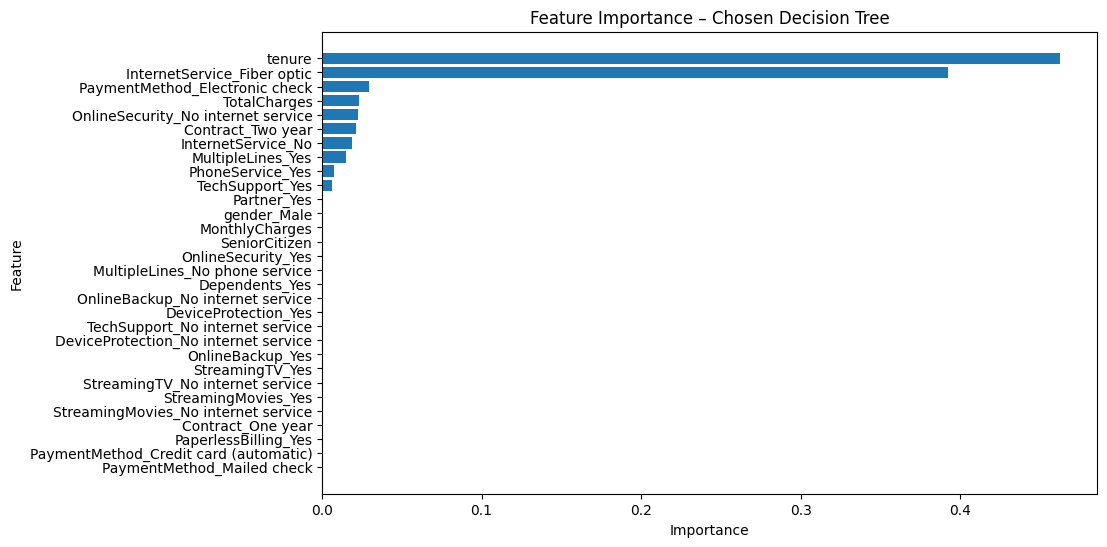

In [35]:
# Task 18 — extract and visualize feature importances


# Get feature importance from chosen model
importance = chosen_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance – Chosen Decision Tree")
plt.gca().invert_yaxis()

plt.show()

**Answer 18 (top 3–5 features):**
The 5 most important features according to the chosen Decision Tree are [tenure], [InternetService_Fiber optic], [PaymentMethod_Electronic check ], [TotalCharges], and [OnlineSecurity_No internet service]. These features had the highest feature-importance values and therefore contributed most to the model's decision-making.

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
The top features identified by the Decision Tree are generally consistent with the patterns observed in the Lab 2 EDA. Features such as [   tenure], [InternetService_Fiber optic], and [PaymentMethod_Electronic check] were also associated with differences in customer churn during the EDA, suggesting that the model has learned meaningful patterns in the data.

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
I built a Decision Tree classification model to predict whether a customer will churn or not. After comparing different tree depths, I selected a max_depth of [23] because it provided a good balance between training and test performance and reduced overfitting. The chosen model achieved an accuracy of [73%], precision of [49%], recall of [48%], and F1-score of [48%] on the test set. The main limitation is that a single Decision Tree can still overfit and may not capture complex relationships as effectively as more advanced models. In addition, class imbalance means that accuracy alone is not sufficient to judge the model's performance.

**Answer 21 — Next steps:**
If I had more time, I would try other algorithms such as Random Forest, Gradient Boosting, or XGBoost and compare their performance with the Decision Tree. I would also explore additional feature engineering and techniques for handling class imbalance, such as class weights or resampling methods. Finally, I would tune the model's hyperparameters using cross-validation to find a model that generalizes better to unseen customers.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted